# E2 — One Success Isn't Reliability

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute end-to-end success for a multi-step workflow and see why "each step is 90% reliable" is not reassuring
- Distinguish **pass@1** (did one run succeed?) from **pass^k** (did *every* one of k runs succeed?) and simulate both
- Show, from a published pass@1 / pass^20 pair, that agent runs are **not** independent — and fit the task-difficulty distribution that explains the gap
- Build **Wilson** score intervals, measure their coverage against the textbook **Wald** interval, and see Wald fail outright near 100%
- Answer the question your project needs answered: *how many runs before I am allowed to claim my system is better?*

## 🔗 Where this fits

**Builds on:** Course 12 — Unit 4, lesson 01 `examples/01_model_evaluation_optimization.ipynb`, whose Part 5
evaluated the final model **once** on the untouched test set and reported a single number. That is the right
discipline for a fixed classifier on a fixed test set. This notebook asks what happens when the thing you are
evaluating is **stochastic** — when re-running it gives a different answer — which is true of every agent,
every LLM-backed component, and every pipeline with a retry in it. It also builds on Course 03 (AIAT 113) —
Unit 5, lesson 08 `examples/08_pvalues_confidence_intervals.ipynb`, where you first computed a confidence
interval; here you will find out that the interval formula taught there breaks at the exact place agent
results live.

**Used later in:** Course 12 — Unit 5, where your results chapter has to state a number *and* an interval,
and where "we ran it once and it worked" is the single most common reason a graduation project's evaluation
section is sent back.

## 🌍 Why this matters: 65.36% became 25.25% when they pressed *run* twenty times

In August 2026 a Microsoft team released **Thinkingbox**, a sandbox and benchmark for agents working inside
*stateful business workflows* — 507 policy-conditioned tasks across retail, hospitality, auto insurance,
neobank internal IT, and consulting IT/HR support. Every attempt is graded by executable checks against the
final state of the backend, not by whether the answer *looked* right.

Their headline result is one sentence long and it should change how you write your project report:

> *"Across proprietary and open-weight models, the strongest achieves **65.36% pass@1**, but only
> **25.25% pass^20**."* — Li et al., 2026 ([arXiv:2608.19741](https://arxiv.org/abs/2608.19741))

`pass@1` is what a demo shows you: run the task once, it worked. `pass^20` is what a customer experiences:
run the same task twenty times and it worked **every single time**. The best system in that study loses
roughly two thirds of its apparent capability the moment you ask it to be consistent. The authors also note
that many failed attempts "show clean termination and valid state-changing actions" — the agent finished
tidily and did the wrong thing, so no exception, no error log, no alert.

**What goes wrong without this lesson.** A graduation project that reports "our agent completed the task"
after one successful run has measured almost nothing, and the same is true of a model whose accuracy came
from a single train/test split with an unfixed seed. This is not a student-only failure. Zhu et al. audited
widely used agent benchmarks and found concrete defects — *SWE-bench Verified uses insufficient test cases,
τ-bench counts empty responses as successful* — which "can lead to under- or overestimation of agents'
performance by up to 100% in relative terms"; applying their Agentic Benchmark Checklist to CVE-Bench cut the
overestimation by 33% ([arXiv:2507.02825](https://arxiv.org/abs/2507.02825)). And Rabanser et al. argue the
deeper point: compressing behaviour into one success metric "obscures critical operational flaws", so they
decompose reliability into consistency, robustness, predictability and safety across twelve metrics — and,
evaluating 15 models on two benchmarks, find recent capability gains produced only small reliability gains
([arXiv:2602.16666](https://arxiv.org/abs/2602.16666)).

Nothing in this notebook requires a model. All of it is arithmetic you can do for your own project this week.

## 📥 Inputs & 📤 Outputs

**Inputs:** no files and no network. Two things are declared in code: a six-step workflow with a stated
per-step success probability for each step, and two published numbers (`pass@1 = 0.6536`, `pass^20 = 0.2525`)
quoted from arXiv:2608.19741. Randomness is used deliberately — repeated runs *are* the subject of the
lesson — with fixed seeds so your output matches the text.

> **Honest label — where the step probabilities come from.** The six per-step numbers are *assumptions we
> declare*, not measurements. They are the input to a simulation whose purpose is to show you the arithmetic
> of composition. Change them to your own project's measured step rates and every conclusion below recomputes.
> The two Thinkingbox numbers, by contrast, are published measurements and are labelled as such wherever
> they appear.

**Outputs:** an end-to-end success rate with its failure breakdown by step; a pass^k decay curve (simulated
and analytic); a fitted Beta distribution of per-task difficulty; a Wilson-vs-Wald coverage table; and a chart
of "probability of ranking two systems the wrong way round" against the number of runs.

## Part 1: Six Reliable Steps Make One Unreliable Workflow

Here is a workflow of the kind your capstone might automate: a customer asks for a refund, and the system has
to read the request, find the account, check the policy, compute the amount, call the payments API, and write
a record. Six steps. Suppose you measured each step on its own and each one is between 88% and 98% correct —
numbers most people would call good.

Multiply them.

In [1]:
# WHAT: define a six-step workflow, give each step a success probability, then simulate the whole
#       workflow many times and count how often ALL six steps succeed in the same run.
# WHY:  reliability composes by MULTIPLICATION, not by averaging. Students consistently reason about
#       "our steps are ~92% accurate" as if the workflow were 92% accurate. It is not, and the gap
#       grows with every step you add.
import numpy as np
import pandas as pd

# Each tuple is (step name, probability that THIS step succeeds on a given run).
# These probabilities are declared assumptions (see the honest label above), not measurements.
STEPS = [
    ("1. Read the customer's request",      0.98),
    ("2. Look up the account in the CRM",   0.95),
    ("3. Check the refund policy document", 0.92),
    ("4. Compute the refund amount",        0.90),
    ("5. Call the payments API",            0.88),
    ("6. Write the confirmation record",    0.94),
]
names = [s for s, _ in STEPS]
p_step = np.array([p for _, p in STEPS])

N_RUNS = 20_000
rng = np.random.default_rng(0)                      # fixed seed: your numbers will match the text

# draws[run, step] is True when that step succeeded on that run. Steps are independent HERE by
# construction — Part 2 is where we find out that real agent runs are not.
draws = rng.random((N_RUNS, len(p_step))) < p_step
run_succeeded = draws.all(axis=1)                   # the run works only if every step works

print(f"{'step':38s} {'P(step ok)':>11s}   {'P(all steps up to here)':>24s}")
running = 1.0
for name, p in STEPS:
    running *= p
    print(f"{name:38s} {p:11.2f}   {running:24.4f}")

print()
print(f"Analytic end-to-end success (product of the six) : {p_step.prod():.4f}")
print(f"Simulated end-to-end success ({N_RUNS:,} runs)     : {run_succeeded.mean():.4f}")
print(f"Mean per-step success rate                       : {p_step.mean():.4f}   <- the number people quote")
print()
print(f"So a workflow whose average step is {p_step.mean():.0%} reliable finishes correctly "
      f"{p_step.prod():.0%} of the time.")

step                                    P(step ok)    P(all steps up to here)
1. Read the customer's request                0.98                     0.9800
2. Look up the account in the CRM             0.95                     0.9310
3. Check the refund policy document           0.92                     0.8565
4. Compute the refund amount                  0.90                     0.7709
5. Call the payments API                      0.88                     0.6784
6. Write the confirmation record              0.94                     0.6377

Analytic end-to-end success (product of the six) : 0.6377
Simulated end-to-end success (20,000 runs)     : 0.6417
Mean per-step success rate                       : 0.9283   <- the number people quote

So a workflow whose average step is 93% reliable finishes correctly 64% of the time.


In [2]:
# WHAT: for every failed run, record WHICH step broke first, and turn that into a table.
# WHY:  "the workflow fails 36% of the time" is not actionable. "Step 5 is responsible for more
#       failures than steps 1, 2 and 6 combined" tells you where to spend the next sprint.
first_failure = np.where(run_succeeded, -1, np.argmax(~draws, axis=1))
failed = first_failure[first_failure >= 0]

breakdown = pd.DataFrame({
    "step": names,
    "P(step ok)": p_step,
    "runs where this step failed first": [int((failed == i).sum()) for i in range(len(names))],
})
breakdown["share of all failures"] = breakdown["runs where this step failed first"] / len(failed)

print(f"Failed runs: {len(failed):,} of {N_RUNS:,}  ({len(failed) / N_RUNS:.1%})\n")
print(breakdown.to_string(index=False, formatters={
    "P(step ok)": "{:.2f}".format, "share of all failures": "{:.1%}".format}))
print()
worst = breakdown.loc[breakdown["share of all failures"].idxmax()]
print(f"Largest single source of failure: {worst['step']} "
      f"({worst['share of all failures']:.1%} of all failed runs).")
print("Note that step 1 has the highest reliability AND still causes failures — every step does.")

Failed runs: 7,167 of 20,000  (35.8%)

                               step P(step ok)  runs where this step failed first share of all failures
     1. Read the customer's request       0.98                                438                  6.1%
  2. Look up the account in the CRM       0.95                                958                 13.4%
3. Check the refund policy document       0.92                               1424                 19.9%
       4. Compute the refund amount       0.90                               1744                 24.3%
           5. Call the payments API       0.88                               1842                 25.7%
   6. Write the confirmation record       0.94                                761                 10.6%

Largest single source of failure: 5. Call the payments API (25.7% of all failed runs).
Note that step 1 has the highest reliability AND still causes failures — every step does.


## Part 2: pass@1 Against pass^k — and Proof That Runs Are Not Independent

Two ways to report the same system:

- **pass@1** — the fraction of tasks solved in a single attempt. This is the number on every leaderboard.
- **pass^k** — the fraction of tasks solved in **all** of *k* independent attempts. This is the number your
  operations team cares about, because they will run the workflow more than once.

Start with the naive model. If a task succeeds independently with probability *p* on every attempt, then
pass^k = *p*ᵏ, and the decay is brutal. Now confront that model with the published pair:
**pass@1 = 65.36%, pass^20 = 25.25%** (arXiv:2608.19741). Under independence, 0.6536²⁰ is a number with three
zeros after the decimal point. The measured value is 25%. The independence model is not slightly wrong —
it is off by three orders of magnitude, and the next cell shows exactly that.

In [3]:
# WHAT: simulate pass^k for our six-step workflow, then check the independence prediction against
#       the two PUBLISHED Thinkingbox numbers.
# WHY:  this is the moment the naive model dies. If runs were independent, a 65% pass@1 system would
#       succeed 20-for-20 about two times in ten thousand. The measured rate is one in four.
K_MAX = 20
sim_pass_k, analytic_pass_k = [], []
for k in range(1, K_MAX + 1):
    # k independent repetitions of the whole workflow, for each of N_RUNS "tasks"
    reps = (rng.random((N_RUNS, k, len(p_step))) < p_step).all(axis=2)   # [task, repetition]
    sim_pass_k.append(reps.all(axis=1).mean())
    analytic_pass_k.append(p_step.prod() ** k)

print("Our simulated workflow (steps independent BY CONSTRUCTION):")
print(f"{'k':>3s} {'simulated pass^k':>18s} {'p^k (analytic)':>16s}")
for k in (1, 2, 5, 10, 20):
    print(f"{k:3d} {sim_pass_k[k-1]:18.4f} {analytic_pass_k[k-1]:16.4f}")

PUB_PASS1, PUB_PASS20 = 0.6536, 0.2525      # PUBLISHED, Li et al. 2026, arXiv:2608.19741
print("\n--- Published measurement vs the independence model -------------------------------")
print(f"Thinkingbox-bench, strongest model : pass@1  = {PUB_PASS1:.4f}   (published)")
print(f"Thinkingbox-bench, strongest model : pass^20 = {PUB_PASS20:.4f}   (published)")
print(f"Independence would predict pass^20 = {PUB_PASS1 ** 20:.6f}")
print(f"Ratio measured / predicted         = {PUB_PASS20 / PUB_PASS1 ** 20:,.0f}x")
print("\nThe independence model is wrong by three orders of magnitude. Something else is going on.")

Our simulated workflow (steps independent BY CONSTRUCTION):
  k   simulated pass^k   p^k (analytic)
  1             0.6414           0.6377
  2             0.4012           0.4066
  5             0.1047           0.1054
 10             0.0110           0.0111
 20             0.0003           0.0001

--- Published measurement vs the independence model -------------------------------
Thinkingbox-bench, strongest model : pass@1  = 0.6536   (published)
Thinkingbox-bench, strongest model : pass^20 = 0.2525   (published)
Independence would predict pass^20 = 0.000202
Ratio measured / predicted         = 1,247x

The independence model is wrong by three orders of magnitude. Something else is going on.


### What is going on: tasks are not equally hard

The missing ingredient is **heterogeneity**. A benchmark is not one task repeated; it is 507 different tasks.
Some are nearly always solved, some are nearly never solved, and the average of those is what pass@1 reports.

Write *p<sub>i</sub>* for the per-attempt success probability of task *i*. Then

- pass@1 = mean( *p<sub>i</sub>* )
- pass^k = mean( *p<sub>i</sub>*ᵏ )

and by Jensen's inequality mean(*p*ᵏ) ≥ mean(*p*)ᵏ — heterogeneity **raises** pass^k above the independence
prediction. So we can invert the published pair: find the spread of task difficulty that reproduces
*both* numbers at once. Model the *p<sub>i</sub>* as Beta(*a*, *b*), fix the mean to 0.6536, and solve for the
one remaining degree of freedom so that E[*p*²⁰] = 0.2525.

In [4]:
# WHAT: fit a Beta distribution of per-task success probability that reproduces BOTH published
#       numbers (mean = pass@1 = 0.6536 and E[p^20] = pass^20 = 0.2525), then read off its shape.
# WHY:  it converts an unexplained gap into a statement about the benchmark: the model is not
#       "65% good at everything", it is nearly perfect on some tasks and nearly hopeless on others.
from scipy import optimize, special, stats

def beta_moment_k(concentration, mean=PUB_PASS1, k=20):
    """E[p^k] for p ~ Beta(a, b) with a + b = concentration and a / (a + b) = mean."""
    a, b = mean * concentration, concentration - mean * concentration
    return np.exp(special.gammaln(a + k) + special.gammaln(a + b)
                  - special.gammaln(a) - special.gammaln(a + b + k))

# As concentration -> 0 all mass sits at 0 and 1 (E[p^20] -> pass@1); as it -> infinity every task is
# identical (E[p^20] -> pass@1^20). The measured 0.2525 sits between, so a unique solution exists.
concentration = optimize.brentq(lambda c: beta_moment_k(c) - PUB_PASS20, 1e-3, 1e4)
a_fit = PUB_PASS1 * concentration
b_fit = concentration - a_fit

print(f"Fitted per-task difficulty: Beta(a={a_fit:.3f}, b={b_fit:.3f})")
print(f"  reproduces pass@1  = {a_fit / (a_fit + b_fit):.4f}   (target {PUB_PASS1})")
print(f"  reproduces pass^20 = {beta_moment_k(concentration):.4f}   (target {PUB_PASS20})")
print(f"\nBoth shape parameters are below 1, so the density is U-shaped — mass piles up at the ends:")
print(f"  tasks the model solves >95% of the time : {1 - stats.beta.cdf(0.95, a_fit, b_fit):.1%}")
print(f"  tasks the model solves  <5% of the time : {stats.beta.cdf(0.05, a_fit, b_fit):.1%}")
print(f"  median task success probability         : {stats.beta.ppf(0.5, a_fit, b_fit):.3f}")
print("\nRead that back in words: this system is not uniformly 65% capable. It has a set of tasks it")
print("essentially owns and a set it essentially cannot do, and 'pass@1 = 65%' averages the two into")
print("a number that describes neither.")

Fitted per-task difficulty: Beta(a=0.664, b=0.352)
  reproduces pass@1  = 0.6536   (target 0.6536)
  reproduces pass^20 = 0.2525   (target 0.2525)

Both shape parameters are below 1, so the density is U-shaped — mass piles up at the ends:
  tasks the model solves >95% of the time : 28.6%
  tasks the model solves  <5% of the time : 6.0%
  median task success probability         : 0.768

Read that back in words: this system is not uniformly 65% capable. It has a set of tasks it
essentially owns and a set it essentially cannot do, and 'pass@1 = 65%' averages the two into
a number that describes neither.


## 💬 Discuss

1. The fitted difficulty distribution is U-shaped: many tasks are nearly always solved, a smaller group
   nearly never. If that is the true picture, is a single headline accuracy the *wrong summary*, or the
   *right summary badly presented*? What would you print instead, in one line, on a leaderboard?
2. Our six-step simulation assumed steps fail independently. Name two mechanisms in a real pipeline that
   make consecutive steps fail **together** (hint: one is about the input, one is about state left behind by
   the previous attempt). Would each mechanism push measured pass^k above or below the independence curve?
3. Suppose your project's agent gets pass@1 = 0.80 and pass^5 = 0.70. A classmate says "great, it is
   basically deterministic". What does that pair actually tell you about the shape of your task difficulty,
   and what would you have to measure to distinguish "one broken task type" from "uniform 80% flakiness"?

## Part 3: Your Interval Formula Breaks Exactly Where Agents Live

You ran the workflow 10 times and it succeeded 10 times. What do you report?

The textbook **Wald** interval — the one in Course 03, Unit 5, lesson 08 — is
p̂ ± z·√(p̂(1−p̂)/n). At p̂ = 1 the square root is zero, so the interval is **[1.00, 1.00]**: the formula
claims certainty from ten runs. That is not conservative, it is wrong, and it is wrong in the region where
agent and LLM results actually sit (85–100%).

The **Wilson score** interval solves the correct inequality instead of approximating it, never leaves
[0, 1], and never collapses. We will implement both and then *measure* how often each one contains the true
value — coverage is a property you can check by simulation, not a claim you have to accept.

In [5]:
# WHAT: implement Wald and Wilson intervals, print them for the cases that matter, then measure the
#       actual coverage of each by simulation.
# WHY:  an interval that claims 95% confidence and contains the truth 40% of the time is worse than
#       no interval, because it launders a guess into a result.
def wald_interval(x, n, conf=0.95):
    """Textbook normal approximation. Collapses to a point at x == 0 or x == n."""
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    p_hat = x / n
    half = z * np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat - half, p_hat + half           # deliberately NOT clipped, so you can see it escape [0,1]

def wilson_interval(x, n, conf=0.95):
    """Wilson score interval: solve the normal inequality for p instead of plugging in p_hat."""
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    p_hat = x / n
    denom = 1 + z**2 / n
    centre = (p_hat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

print(f"{'runs':>12s}  {'Wald 95%':>22s}  {'Wilson 95%':>22s}  {'Wilson width':>12s}")
for x, n in [(1, 1), (10, 10), (8, 10), (13, 20), (65, 100), (654, 1000)]:
    wl, wh = wald_interval(x, n)
    sl, sh = wilson_interval(x, n)
    print(f"{f'{x}/{n}':>12s}  {f'[{wl:.3f}, {wh:.3f}]':>22s}  {f'[{sl:.3f}, {sh:.3f}]':>22s}  {sh - sl:12.3f}")

print("\nRead row 2: ten successes out of ten. Wald says the success rate is exactly 1.000 with no")
print("uncertainty. Wilson says it could plausibly be as low as 0.72 — which is the honest answer,")
print("and it is also the 'rule of three': with 0 failures in n runs the true failure rate can still")
print(f"be about 3/n = {3/10:.2f}.")

        runs                Wald 95%              Wilson 95%  Wilson width
         1/1          [1.000, 1.000]          [0.207, 1.000]         0.793
       10/10          [1.000, 1.000]          [0.722, 1.000]         0.278
        8/10          [0.552, 1.048]          [0.490, 0.943]         0.453
       13/20          [0.441, 0.859]          [0.433, 0.819]         0.386
      65/100          [0.557, 0.743]          [0.553, 0.736]         0.184
    654/1000          [0.625, 0.683]          [0.624, 0.683]         0.059

Read row 2: ten successes out of ten. Wald says the success rate is exactly 1.000 with no
uncertainty. Wilson says it could plausibly be as low as 0.72 — which is the honest answer,
and it is also the 'rule of three': with 0 failures in n runs the true failure rate can still
be about 3/n = 0.30.


In [6]:
# WHAT: measure coverage. Draw many datasets from a KNOWN true rate, build both intervals from each,
#       and count how often the interval actually contains the truth.
# WHY:  "95% confidence" is a testable claim about a procedure. Test it.
rng_cov = np.random.default_rng(1)
M_SIM = 20_000

rows = []
for p_true in (0.65, 0.90, 0.95):
    for n in (10, 30, 100):
        xs = rng_cov.binomial(n, p_true, M_SIM)
        wald_hit = np.mean([lo <= p_true <= hi for lo, hi in (wald_interval(x, n) for x in xs)])
        wilson_hit = np.mean([lo <= p_true <= hi for lo, hi in (wilson_interval(x, n) for x in xs)])
        rows.append({"true rate": p_true, "runs n": n,
                     "Wald coverage": wald_hit, "Wilson coverage": wilson_hit})

coverage = pd.DataFrame(rows)
print("Nominal confidence is 95% for both columns. Anything far below 0.95 is a broken promise.\n")
print(coverage.to_string(index=False, formatters={
    "true rate": "{:.2f}".format, "Wald coverage": "{:.3f}".format, "Wilson coverage": "{:.3f}".format}))

worst_wald = coverage.loc[coverage["Wald coverage"].idxmin()]
print(f"\nWorst Wald cell: true rate {worst_wald['true rate']:.2f}, n = {int(worst_wald['runs n'])} -> "
      f"{worst_wald['Wald coverage']:.1%} coverage from a '95%' interval.")
print("That is the region a good agent lives in. Use Wilson.")

Nominal confidence is 95% for both columns. Anything far below 0.95 is a broken promise.

true rate  runs n Wald coverage Wilson coverage
     0.65      10         0.886           0.963
     0.65      30         0.913           0.947
     0.65     100         0.942           0.957
     0.90      10         0.651           0.928
     0.90      30         0.808           0.976
     0.90     100         0.933           0.937
     0.95      10         0.396           0.913
     0.95      30         0.782           0.942
     0.95     100         0.875           0.965

Worst Wald cell: true rate 0.95, n = 10 -> 39.6% coverage from a '95%' interval.
That is the region a good agent lives in. Use Wilson.


## Part 4: The Comparative Experiment — How Many Runs Buys You a Claim?

**Baseline.** Two systems. A really is better: it succeeds 65% of the time, B succeeds 55%. You evaluate each
with **one run**, and declare the winner.

**Change one thing.** Evaluate each with *n* runs instead of one, and declare the winner by observed count.

**Re-run and read the number.** We repeat that whole procedure 20,000 times at each *n* and count how often
the declared winner is wrong. Nothing else changes: same systems, same true gap, same decision rule. Only the
number of runs moves.

In [7]:
# WHAT: for a range of run counts n, simulate the full "evaluate both, pick the winner" procedure
#       20,000 times and record how often the worse system is declared the winner.
# WHY:  this turns "you need more runs" from advice into a number you can put in a project plan.
P_A, P_B = 0.65, 0.55            # the truth: A is better by 10 percentage points
rng_rank = np.random.default_rng(2)
M_TRIALS = 20_000
n_values = [1, 3, 5, 10, 20, 50, 100, 200]

rank_rows = []
for n in n_values:
    a_wins_count = rng_rank.binomial(n, P_A, M_TRIALS)
    b_wins_count = rng_rank.binomial(n, P_B, M_TRIALS)
    p_wrong = float((b_wins_count > a_wins_count).mean())
    p_tie = float((b_wins_count == a_wins_count).mean())
    # a tie forces a coin flip, so half of it is also a wrong answer
    error_rate = p_wrong + p_tie / 2
    sl, sh = wilson_interval(int(round(P_A * n)), n)      # width of the claim you could make at this n
    rank_rows.append({"runs per system": n, "P(pick B, the worse one)": p_wrong,
                      "P(tie)": p_tie, "P(wrong call)": error_rate,
                      "Wilson width at 65%": sh - sl})

ranking = pd.DataFrame(rank_rows)
print(f"True rates: A = {P_A:.0%}, B = {P_B:.0%}. A is better. How often do we say otherwise?\n")
print(ranking.to_string(index=False, formatters={
    "P(pick B, the worse one)": "{:.3f}".format, "P(tie)": "{:.3f}".format,
    "P(wrong call)": "{:.3f}".format, "Wilson width at 65%": "{:.3f}".format}))

one = ranking.loc[ranking["runs per system"] == 1, "P(wrong call)"].iloc[0]
twenty = ranking.loc[ranking["runs per system"] == 20, "P(wrong call)"].iloc[0]
hundred = ranking.loc[ranking["runs per system"] == 100, "P(wrong call)"].iloc[0]
print(f"\nCONCLUSION SUPPORTED BY THESE NUMBERS:")
print(f"  With 1 run each, you call the comparison wrong {one:.0%} of the time - barely better than a coin.")
print(f"  With 20 runs each it is {twenty:.0%}. With 100 runs each it is {hundred:.0%}.")
print(f"  A 10-point true gap needs roughly 100 runs per system before a single comparison is trustworthy.")

True rates: A = 65%, B = 55%. A is better. How often do we say otherwise?

 runs per system P(pick B, the worse one) P(tie) P(wrong call) Wilson width at 65%
               1                    0.193  0.512         0.449               0.793
               3                    0.247  0.306         0.400               0.731
               5                    0.262  0.236         0.380               0.652
              10                    0.244  0.164         0.326               0.519
              20                    0.211  0.101         0.261               0.386
              50                    0.130  0.048         0.154               0.257
             100                    0.063  0.023         0.074               0.184
             200                    0.018  0.005         0.021               0.131

CONCLUSION SUPPORTED BY THESE NUMBERS:
  With 1 run each, you call the comparison wrong 45% of the time - barely better than a coin.
  With 20 runs each it is 26%. With 100 runs

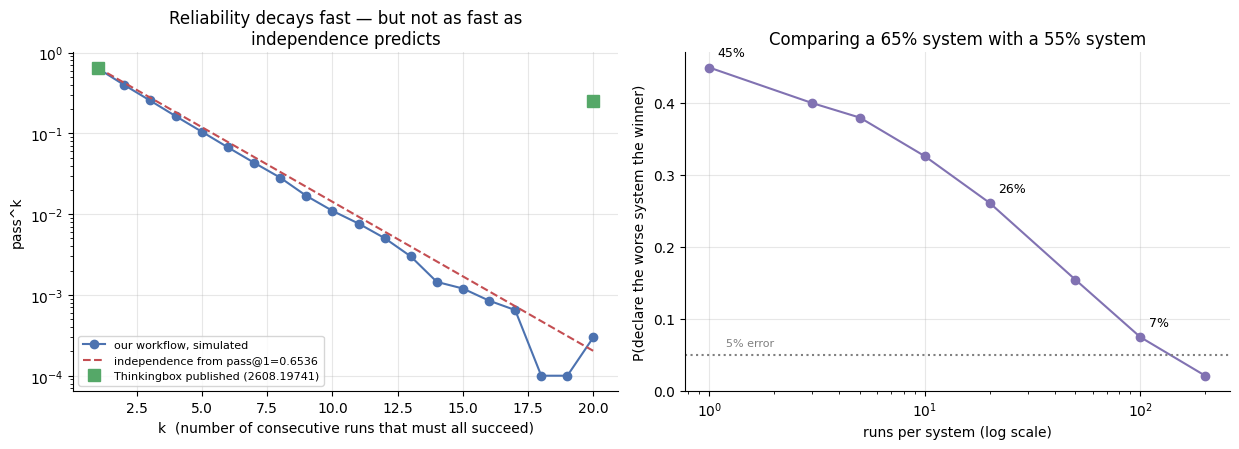

In [8]:
# WHAT: plot the two curves that summarise the whole notebook - pass^k decay, and error rate vs runs.
# WHY:  a table of eight rows is hard to argue with in a meeting; a curve with your own project's
#       operating point marked on it is not.
import matplotlib.pyplot as plt           # the notebook kernel renders figures inline; no window is opened

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

ks = np.arange(1, K_MAX + 1)
ax1.plot(ks, sim_pass_k, "o-", color="#4C72B0", label="our workflow, simulated")
ax1.plot(ks, [PUB_PASS1 ** k for k in ks], "--", color="#C44E52",
         label=f"independence from pass@1={PUB_PASS1}")
ax1.plot([1, 20], [PUB_PASS1, PUB_PASS20], "s", color="#55A868", markersize=9,
         label="Thinkingbox published (2608.19741)")
ax1.set_xlabel("k  (number of consecutive runs that must all succeed)")
ax1.set_ylabel("pass^k")
ax1.set_title("Reliability decays fast — but not as fast as\nindependence predicts")
ax1.set_yscale("log")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(ranking["runs per system"], ranking["P(wrong call)"], "o-", color="#8172B2")
ax2.axhline(0.05, ls=":", color="grey")
ax2.text(1.2, 0.062, "5% error", fontsize=8, color="grey")
for n, e in zip(ranking["runs per system"], ranking["P(wrong call)"]):
    if n in (1, 20, 100):
        ax2.annotate(f"{e:.0%}", (n, e), textcoords="offset points", xytext=(6, 8), fontsize=9)
ax2.set_xscale("log")
ax2.set_xlabel("runs per system (log scale)")
ax2.set_ylabel("P(declare the worse system the winner)")
ax2.set_title("Comparing a 65% system with a 55% system")
ax2.grid(alpha=0.3)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## ✅ Summary

**What you actually did here** — every number below was printed by the cells above, not quoted from memory:

- Multiplied six per-step success probabilities averaging 92.8% into an end-to-end rate of **63.8%**, and
  confirmed it by simulating 20,000 runs
- Attributed failures to the step that broke first, so the result points at work rather than at despair
- Showed that the published pair pass@1 = 65.36% / pass^20 = 25.25% is **1,247 times** what independence
  predicts, and fitted the U-shaped Beta(0.66, 0.35) task-difficulty distribution that reproduces both
- Measured the coverage of a "95%" Wald interval at a true rate of 0.95 with n = 10: it contains the truth
  **39.6%** of the time. Wilson: 91.3%
- Established, by simulation, that separating a 65% system from a 55% system with one comparison needs on the
  order of **100 runs per system** to get the error rate under 10%

**The one sentence to keep:** *a single successful run is a screenshot, not a measurement* — report a rate,
a run count, and a Wilson interval, or report nothing.

**Do this in your own project.** In your Unit 5 results chapter, every stochastic result gets three things:
the number of runs, the point estimate, and the interval. If the intervals for your system and the baseline
overlap, write that they overlap. An honest overlap is a pass; a hidden one is a resubmission.

## ⚠️ Where this breaks

**The six step probabilities are ours, not measurements.** They were declared in Part 1 to make the
arithmetic visible. The *shape* of the conclusion — multiplication, not averaging — is a theorem and holds
for any values; the specific 63.8% is only as good as the inputs. Measure your own steps before quoting a
number to anyone.

**Independence is the assumption doing the most work, and it is usually false.** Real steps fail together:
one malformed input breaks parsing *and* lookup *and* the API call; a failed attempt leaves state behind that
poisons the retry. Part 2 shows heterogeneity *raising* pass^k above the independence line, but positive
correlation between steps within a run pushes end-to-end success the other way. Both effects are real and they
do not cancel. Simulating from a declared table cannot tell you which dominates in your system — only repeated
runs of the real thing can.

**Wilson is better, not correct.** It is still an approximation. Very small n, or a true rate at the exact
boundary, still needs an exact (Clopper–Pearson) interval. And all of this assumes runs are exchangeable — if
your agent gets better within a session because it accumulates context, they are not, and no binomial interval
applies.

**Counting successes is the easy half.** Rabanser et al.'s point is that consistency is only one of four
dimensions; robustness (does it survive a perturbed input?), predictability (does it fail in the same way
twice?) and severity (how bad is the worst failure?) are not captured by any pass rate at all
([arXiv:2602.16666](https://arxiv.org/abs/2602.16666)). An agent that fails safely 35% of the time and one
that occasionally issues an unrecoverable refund have the same pass@1.

**And the grader can be the bug.** Zhu et al. found benchmarks whose *reward design* was wrong — empty
responses scored as successes, insufficient tests — producing errors up to 100% in relative terms
([arXiv:2507.02825](https://arxiv.org/abs/2507.02825)). Before you trust your own repeated-run numbers, run
one deliberately broken system through your evaluation harness and check that it scores zero. If it does not,
your harness is measuring something other than success.

## 📚 References

Repeated-run evaluation, and why single numbers mislead:

1. Zhu, Y., Jin, T., Pruksachatkun, Y., Zhang, A., Liu, S., et al. (2025). *Establishing Best Practices for Building Rigorous Agentic Benchmarks*. [arXiv:2507.02825](https://arxiv.org/abs/2507.02825) — the Agentic Benchmark Checklist; documents concrete reward-design defects in SWE-bench Verified, τ-bench and CVE-Bench.
2. Rabanser, S., Kapoor, S., Kirgis, P., Liu, K., Utpala, S., & Narayanan, A. (2026). *Towards a Science of AI Agent Reliability*. [arXiv:2602.16666](https://arxiv.org/abs/2602.16666) — twelve metrics across consistency, robustness, predictability and safety, evaluated over 15 models and two benchmarks.
3. Li, Z., Ko, Y., Keramati, A., Ferri, N., Palmaz Lopez Pelaez, S., et al. (2026). *One Success Isn't Reliability: Thinkingbox, a Sandbox and Benchmark for Agents in Stateful Business Workflows*. [arXiv:2608.19741](https://arxiv.org/abs/2608.19741) — the source of the 65.36% pass@1 / 25.25% pass^20 pair used throughout this notebook.

The statistics, in their original sources:

4. Wilson, E. B. (1927). *Probable Inference, the Law of Succession, and Statistical Inference*. Journal of the American Statistical Association 22(158), 209–212. [doi:10.1080/01621459.1927.10502953](https://doi.org/10.1080/01621459.1927.10502953) — the score interval implemented in Part 3.
5. Brown, L. D., Cai, T. T., & DasGupta, A. (2001). *Interval Estimation for a Binomial Proportion*. Statistical Science 16(2), 101–133. [doi:10.1214/ss/1009213286](https://doi.org/10.1214/ss/1009213286) — the paper that measured Wald's coverage failure and recommended Wilson; our Part 3 coverage table reproduces its central finding.
6. Hanley, J. A., & Lippman-Hand, A. (1983). *If Nothing Goes Wrong, Is Everything All Right? Interpreting Zero Numerators*. JAMA 249(13), 1743–1745. [doi:10.1001/jama.1983.03330370053031](https://doi.org/10.1001/jama.1983.03330370053031) — the "rule of three" used in Part 3.